Getting output variable: erp
Loading daily erp files...

Getting output variable: jd_vec
Loading daily jd_vec files...

n_facets = 24
Number of faces: 24
1d633a7d751bf693
Getting output variable: erp
Loading daily erp files...

n_facets = 48
Number of faces: 48
4c0d1e00531eef03
Getting output variable: erp
Loading daily erp files...

n_facets = 72
Number of faces: 72
89505de91299e620
Getting output variable: erp
Loading daily erp files...

n_facets = 96
Number of faces: 96
7439074994a9c284
Getting output variable: erp
Loading daily erp files...

n_facets = 120
n_vertices: 62
Number of faces: 120
69e5c5102d632dfd
Getting output variable: erp
Loading daily erp files...

n_facets = 180
n_vertices: 92
Number of faces: 180
31dc3f24c2357668
Getting output variable: erp
Loading daily erp files...

n_facets = 280
n_vertices: 142
Number of faces: 280
494c9d2a43257eb9
Getting output variable: erp
Loading daily erp files...

n_facets = 450
n_vertices: 227
Number of faces: 450
b7eb6f0c3d991c56
Get

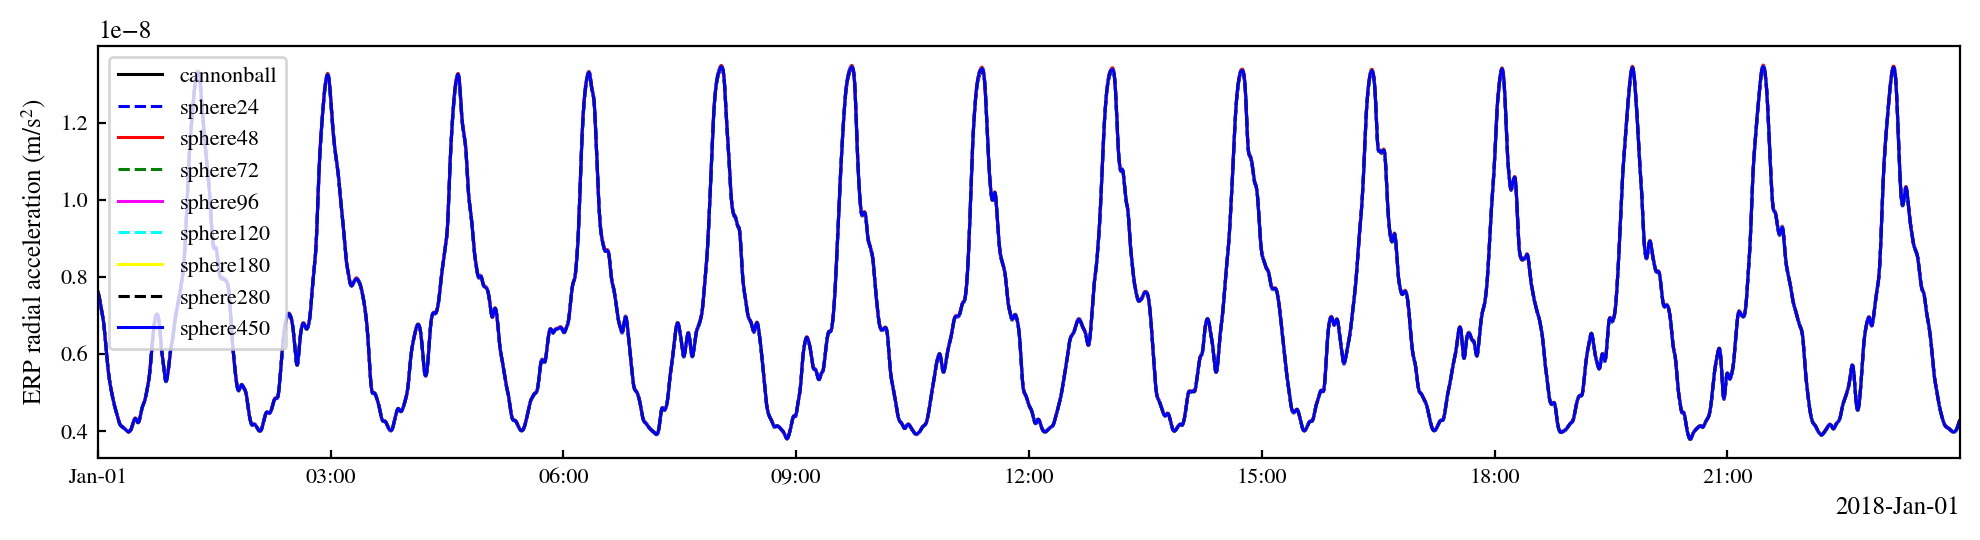

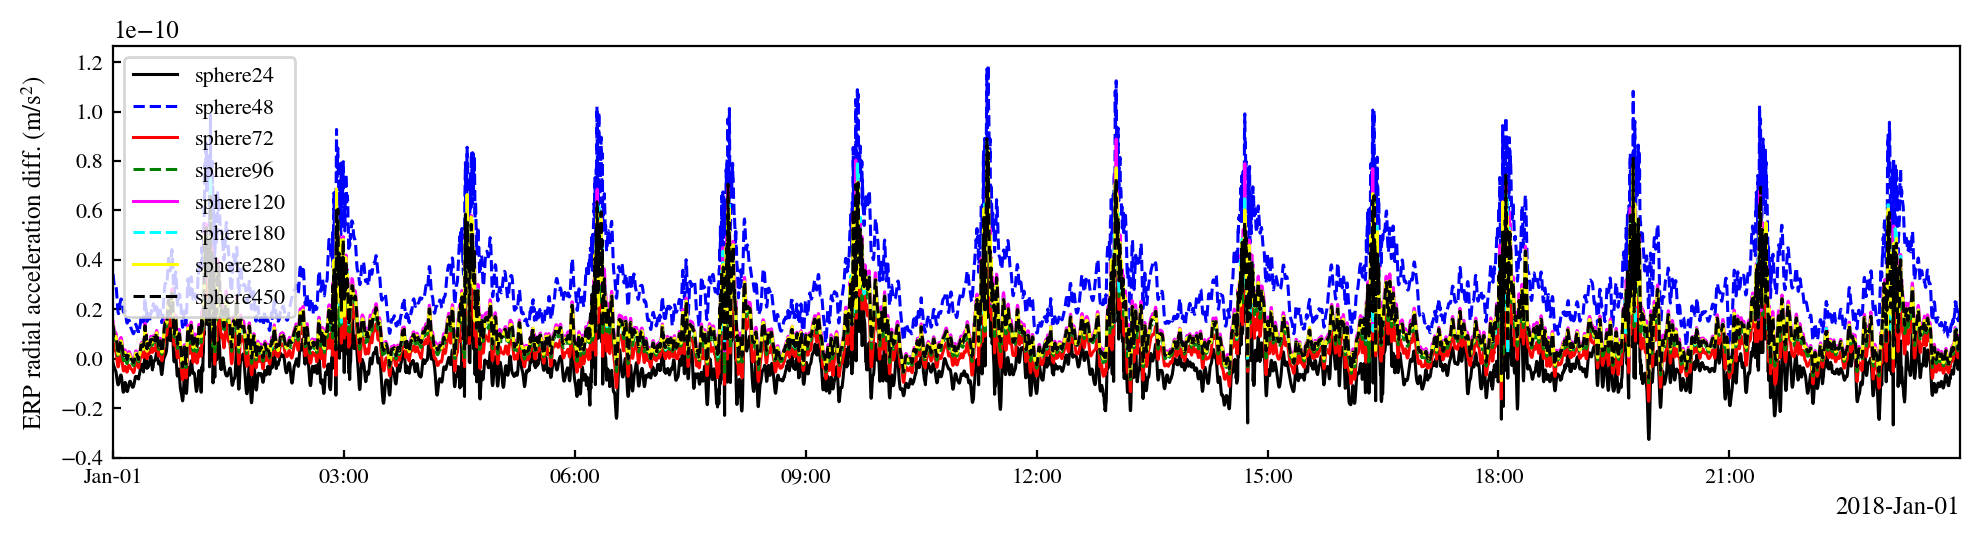

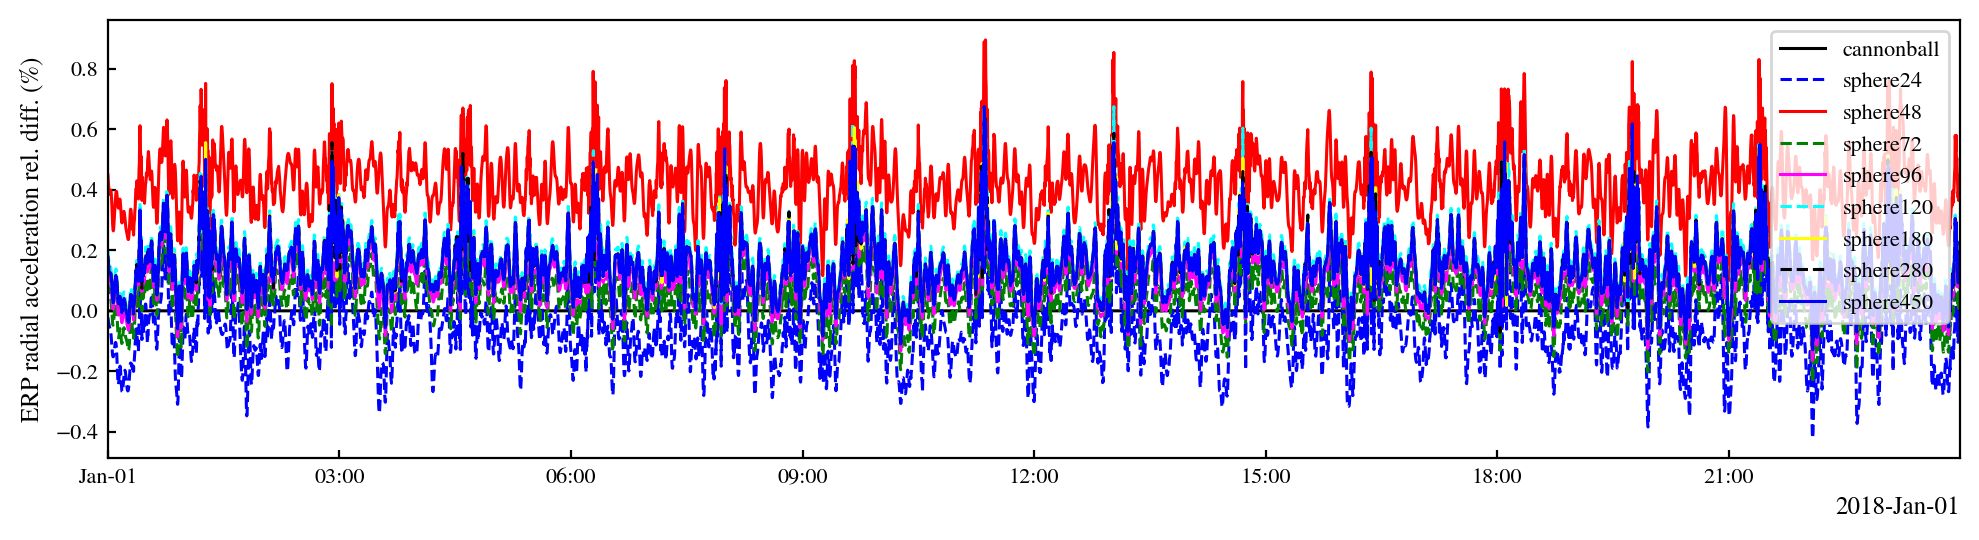

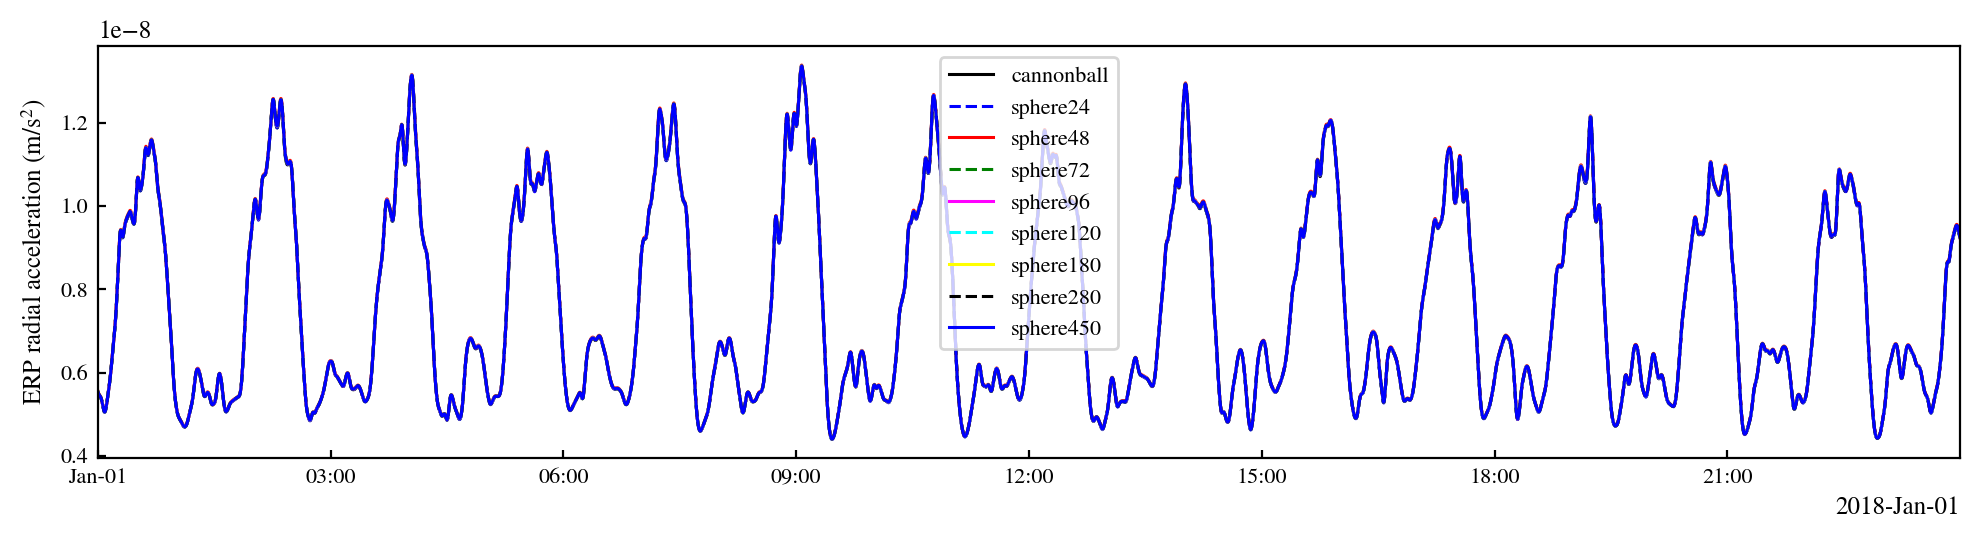

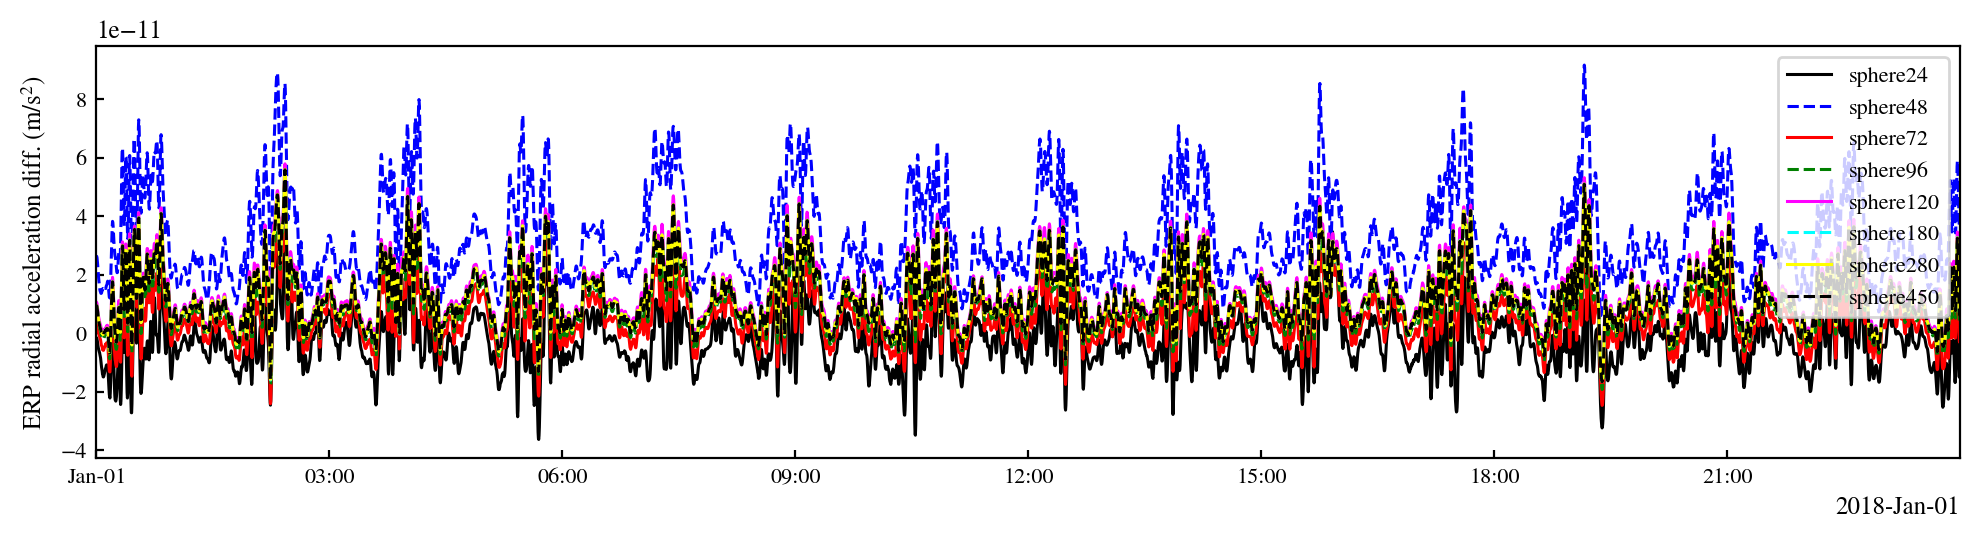

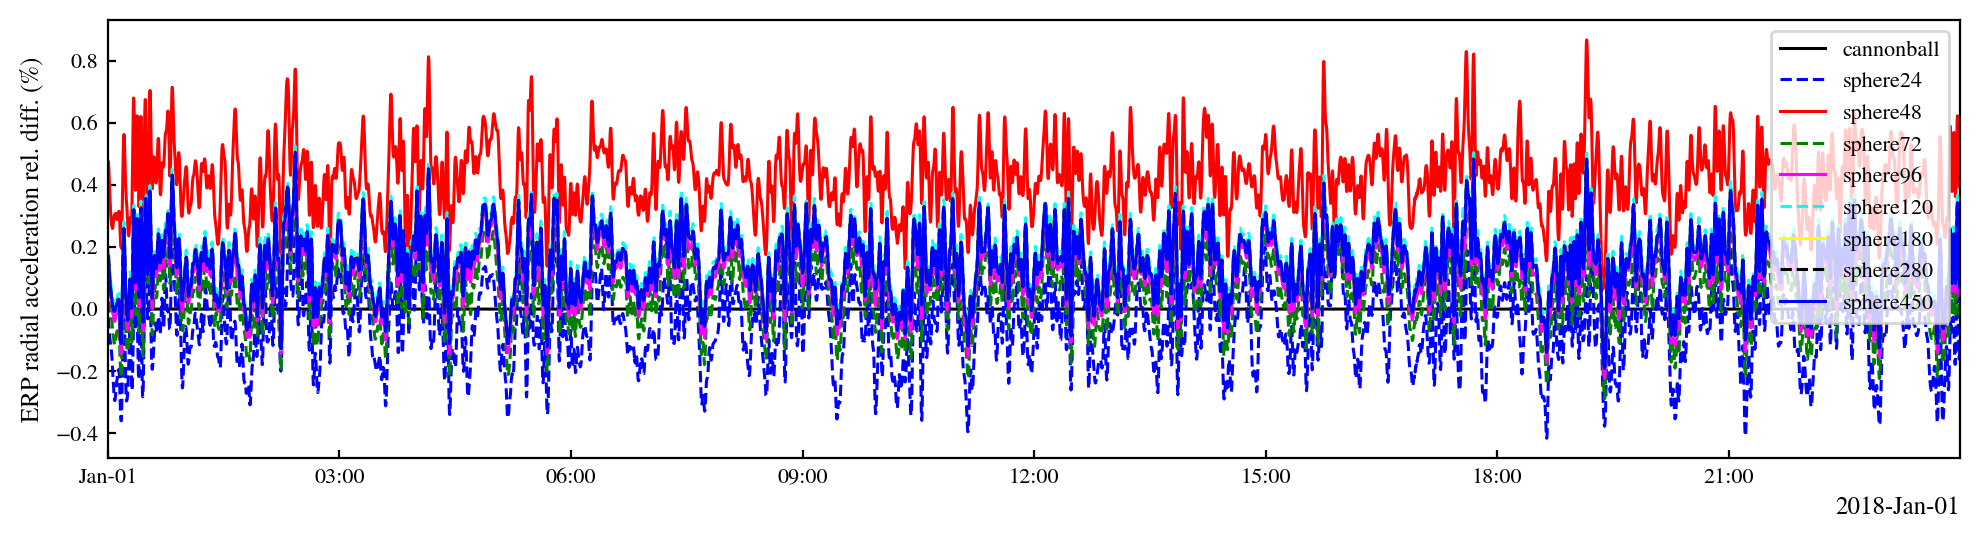

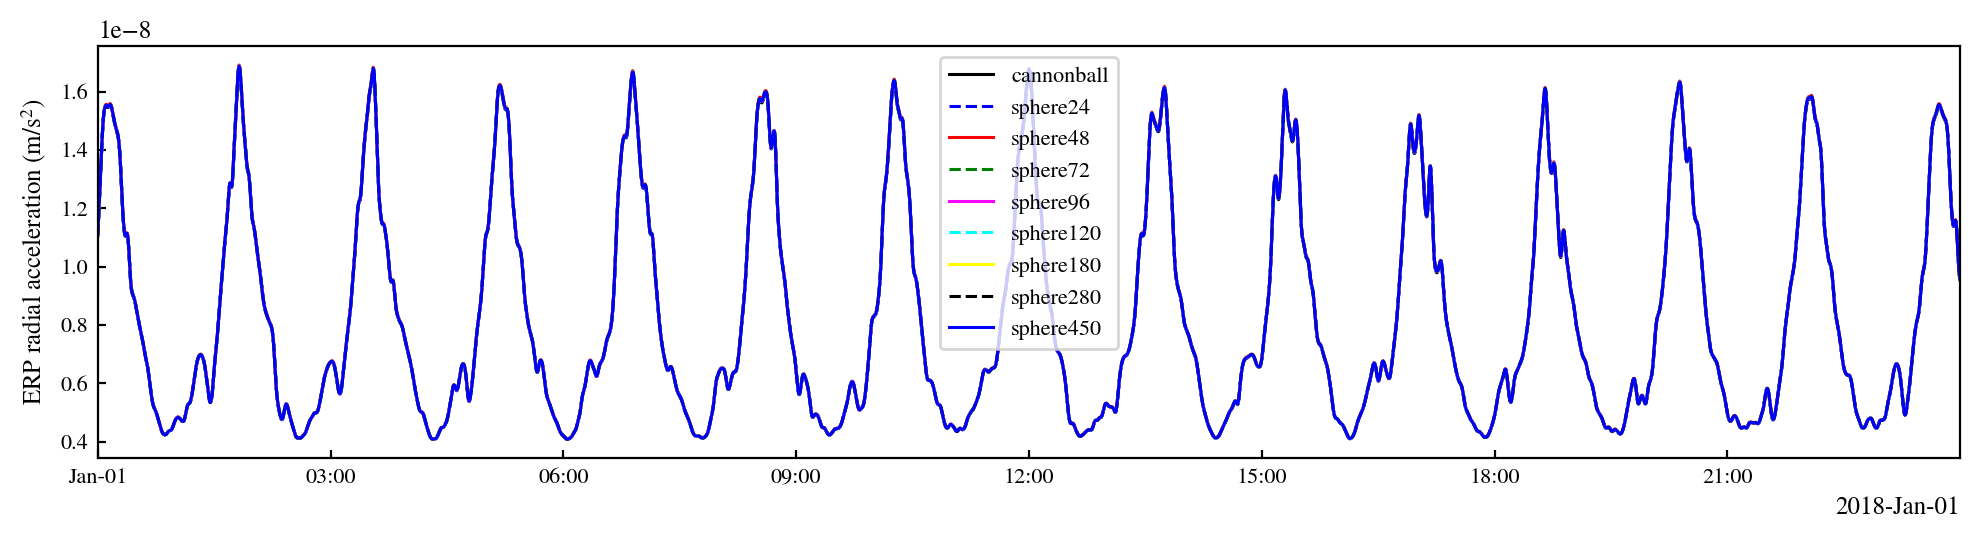

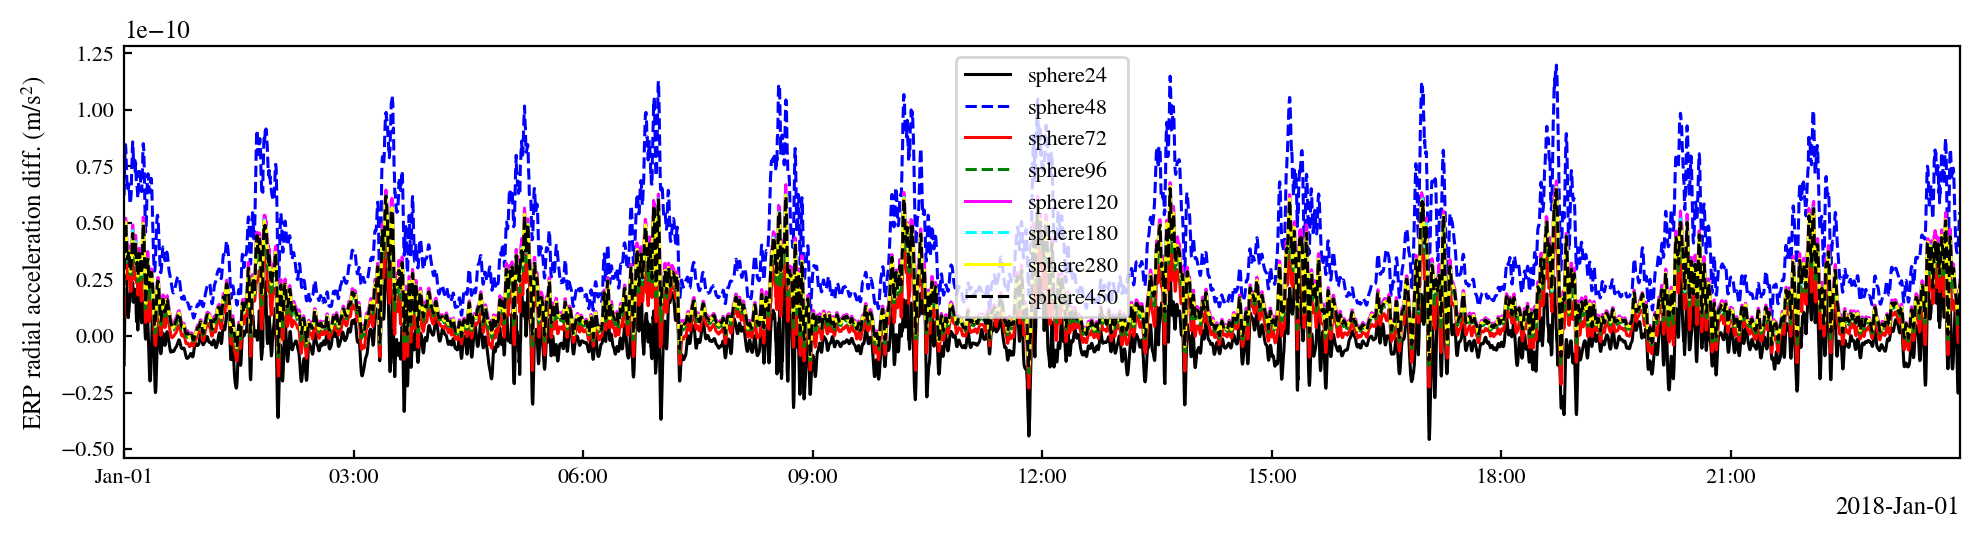

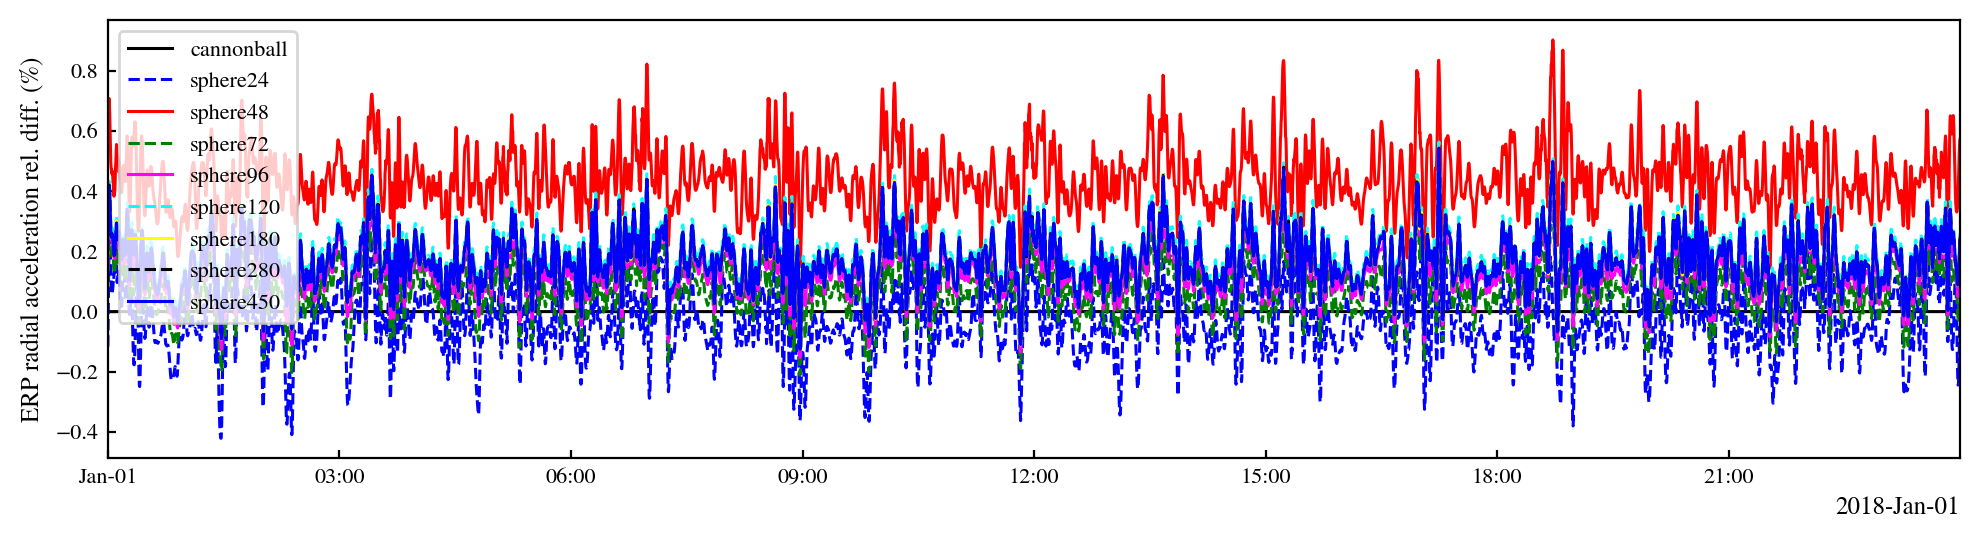

In [8]:
import SpaceBalls.input_database_manager as input_db_manager
from SpaceBalls.postproc_EEI_estimation import get_simulated_accelerometer_measurements, get_output_variable_hist
from SpaceBalls.plotter import Plotter
from SpaceBalls.sph_meshing import fibonacci_sphere, get_faceted_sphere_mesh
import numpy as np

def get_avg_cross_sectional_area(normal_vecs, areas):

    fibonacci_s = -fibonacci_sphere(1, n=1500)
    all_areas = []
    all_vecs = []
    for i, s in enumerate(fibonacci_s):
    #s = np.array([-1, 0, 0])
        total_vec = np.zeros(3)
        total_A = 0

        for n, area in zip(normal_vecs, areas):
            cos = np.max([0, np.dot(-s, n)])
            #vec = area * cos * ((ca+cd) * s - (2/3*cd + 2*cos*cs) * n)
            #total_vec += vec
            total_A += area * cos
        #print(f"cos gamma: {cos}")

        all_areas.append(total_A)
        all_vecs.append(total_vec)
    
    return np.mean(all_areas)


orbits = ['A1', 'G3', 'F12']
n_facets_vec = [24, 48, 72, 96, 120, 180, 280, 450] #, 450]
n_days = 1 

for orbit in orbits:
    y_dict = {}
    desired_sb = {
            'orbit_name': orbit,
            'force_settings': 2,
            'integration_settings': 0,
            'delta_t_out': 15,
            'sc_name': 'SC_0',
        }
    
    keys = input_db_manager.get_primary_keys(desired_sb)
    assert(len(keys)==1)
    key_cannonball = keys[0]
    erp_cannonball = get_output_variable_hist(key_cannonball, n_days, 'erp', save_stacked_file_if_nonexistent=False)
    jd_vec = get_output_variable_hist(key_cannonball, n_days, 'jd_vec', save_stacked_file_if_nonexistent=False)
    y_dict['cannonball'] = erp_cannonball[:,0] * 1e3
    
    radius_meters = 0.5 #input_db_manager.get_dicts(key_cannonball)

    for i, n_facets in enumerate(n_facets_vec):
        print(f"n_facets = {n_facets}")
        mesh = get_faceted_sphere_mesh(radius_meters, n_facets, default_golden=False)
        vertices, centroids, normal_vecs, areas, edge_conns, hull = mesh
        actual_area = get_avg_cross_sectional_area(normal_vecs, areas)
        area_ratio = np.pi*radius_meters**2 / actual_area

        desired_sb['sc_name'] = 'SC_0_'+str(n_facets)
        keys = input_db_manager.get_primary_keys(desired_sb)
        assert(len(keys)==1)
        key_plated = keys[0]
        print(key_plated)
        erp_plated = get_output_variable_hist(key_plated, n_days, 'erp', save_stacked_file_if_nonexistent=False)
        y_dict['sphere'+str(n_facets)] = erp_plated[:,0] * 1e3 * area_ratio

    Plotter.plot_time_series(jd_vec, y_dict, f_height=0.7, f_width=2.5, ylabel='ERP radial acceleration (m/s$^2$)')

    error_dict = y_dict.copy()
    error_dict.pop('cannonball')
    error_dict = {key: series - y_dict['cannonball']  for (key, series) in error_dict.items()}
    Plotter.plot_time_series(jd_vec, error_dict, f_height=0.7, f_width=2.5, ylabel='ERP radial acceleration diff. (m/s$^2$)')

    rel_error_dict = y_dict.copy()
    rel_error_dict = {key: 100 * (series - y_dict['cannonball']) / y_dict['cannonball']  for (key, series) in rel_error_dict.items()}
    Plotter.plot_time_series(jd_vec, rel_error_dict, f_height=0.7, f_width=2.5, ylabel='ERP radial acceleration rel. diff. (%)')

    for (key, val) in rel_error_dict.items():
        print(f"Mean rel. error for {key}: {np.mean(val)}%")

# NEXT: make MONTE S/C rotate!
        

#keys

In [ ]:
from SpaceBalls.sph_meshing import QuadratureGrid, fibonacci_sphere, get_faceted_sphere_mesh

radius_meters = 0.5
n_faces = 280
cs, cd, ca = 1, 0, 0.0

mesh = get_faceted_sphere_mesh(radius_meters, n_faces, default_golden=False)
vertices, centroids, normal_vecs, areas, edge_conns, hull = mesh

def get_avg_cross_sectional_area(normal_vecs, areas):

    fibonacci_s = -fibonacci_sphere(1, n=300)
    all_areas = []
    all_vecs = []
    for i, s in enumerate(fibonacci_s):
    #s = np.array([-1, 0, 0])
        total_vec = np.zeros(3)
        total_A = 0

        for n, area in zip(normal_vecs, areas):
            cos = np.max([0, np.dot(-s, n)])
            vec = area * cos * ((ca+cd) * s - (2/3*cd + 2*cos*cs) * n)
            total_vec += vec
            total_A += area * cos
        #print(f"cos gamma: {cos}")

        all_areas.append(total_A)
        all_vecs.append(total_vec)
    
    return np.mean(all_areas)

A_sphere = np.pi*radius_meters**2
A_faceted = np.mean(all_areas)
A_ratio = A_faceted/A_sphere
print(f"A sphere: {A_sphere}")
print(f"A faceted: {A_faceted}")
print(f"A ratio: {A_ratio}")
#print((A_sphere - A_faceted)/A_sphere)

mean_ACr = np.mean(np.linalg.norm(all_vecs, axis=1))
print(f"Mean ACr: {mean_ACr}")

# Cannonball model:
Cr = 1 + cs + cd*5/3
total_vec_cannonball = np.pi * radius_meters**2 *Cr * s
cannonball_ACr = np.pi * radius_meters**2 *Cr
print(f"Adjusted cannonball ACr: {cannonball_ACr*A_ratio}")
print(f"cannonball ACr: {cannonball_ACr}")
#print((total_vec-total_vec_cannonball)/total_vec_cannonball)



n_vertices: 142
Number of faces: 280
A sphere: 0.7853981633974483
A faceted: 0.7681362334378867
A ratio: 0.9780214281570376
Mean ACr: 0.7681591602409784
Adjusted cannonball ACr: 1.5362724668757735
cannonball ACr: 1.5707963267948966
